In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import logging
import tensorflow as tf
import tensorflow_datasets as tfds

In [3]:
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [4]:
dataset, metadata = tfds.load('mnist', as_supervised=True, with_info=True)
train_dataset, test_dataset = dataset['train'], dataset['test']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

2026-03-09 18:33:28.250804: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-03-09 18:33:28.250992: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-03-09 18:33:28.251086: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-03-09 18:33:28.251580: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-09 18:33:28.251996: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Shuffling /Users/maureentellez/tensorflow_datasets/mnist/incomplete.6M0306_3.0.1/mnist-train.tfrecord*...:   0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /Users/maureentellez/tensorflow_datasets/mnist/incomplete.6M0306_3.0.1/mnist-test.tfrecord*...:   0%…

Dataset mnist downloaded and prepared to /Users/maureentellez/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [7]:
class_names = [
'Cero', 'Uno', 'Dos', 'Tres', 'Cuatro', 'Cinco', 'Seis', 'Siete',
'Ocho', 'Nueve'
]

In [8]:
num_train_examples = metadata.splits['train'].num_examples #60 mil datos train
num_test_examples = metadata.splits['test'].num_examples #10 mil datos test

In [10]:
#Normalizar: Numeros de 0 a 255, que sean de 0 a 1
def normalize(images, labels):
    images = tf.cast(images, tf.float32)
    images /= 255
    return images, labels

In [11]:
train_dataset = train_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)

In [12]:
#Estructura de la red
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)), #Capa de entrada
    tf.keras.layers.Dense(64, activation=tf.nn.relu), #Capas oculta
    tf.keras.layers.Dense(64, activation=tf.nn.relu), #Capas oculta
    tf.keras.layers.Dense(10, activation=tf.nn.softmax) #para clasificacion
])

/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
#Función que compila el modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
#Aprendizaje por lotes de 32 cada lote
BATCHSIZE = 32
train_dataset = train_dataset.repeat().shuffle(num_train_examples).batch(BATCHSIZE)
test_dataset = test_dataset.batch(BATCHSIZE)

In [21]:
#Realizar el aprendizaje
model.fit(
    train_dataset, epochs=5,
    steps_per_epoch=math.ceil(num_train_examples/BATCHSIZE)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.7951 - loss: 7.0053
Epoch 2/5
1505/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7976 - loss: 8.4143

KeyboardInterrupt: 

In [16]:
#Evaluar nuestro modelo ya entrenado, contra el dataset de pruebas
test_loss, test_accuracy = model.evaluate(
test_dataset, steps=math.ceil(num_test_examples/32)
)
#Imprime los resultados de precisión
print("Resultado en las pruebas: ", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8087 - loss: 5.1023
Resultado en las pruebas:  0.8087000250816345


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


2026-03-09 18:42:17.837342: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


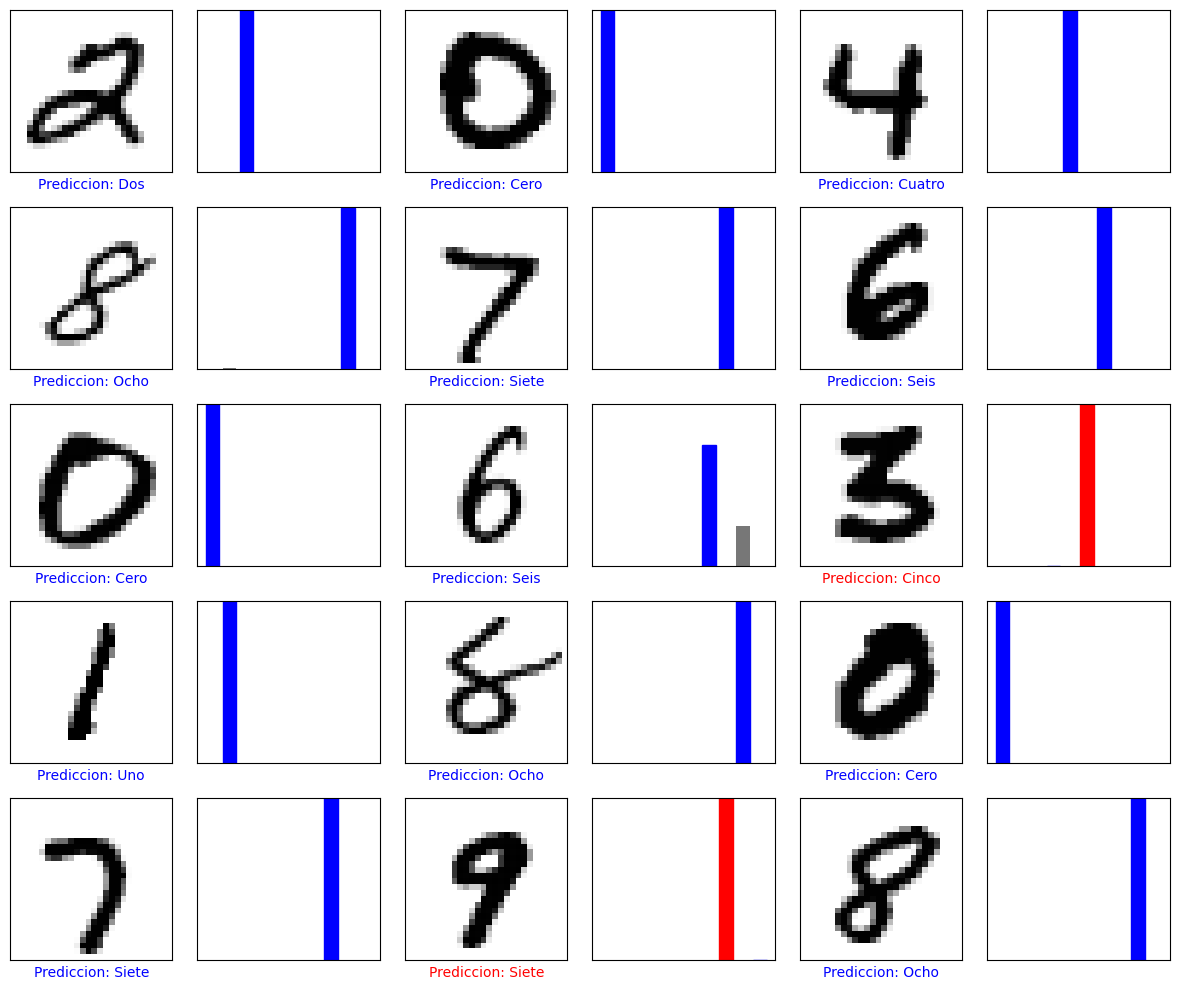

In [20]:
for test_images, test_labels in test_dataset.take(1):
    test_images = test_images.numpy()
    test_labels = test_labels.numpy()
    predictions = model.predict(test_images)

def plot_image(i, predictions_array, true_labels, images):
    predictions_array, true_label, img = predictions_array[i], true_labels[i], images[i]
    
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    
    plt.imshow(img[..., 0], cmap=plt.cm.binary)
    
    predicted_label = np.argmax(predictions_array)
    
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'
        
    plt.xlabel("Prediccion: {}".format(class_names[predicted_label]), color=color)

def plot_value_array(i, predictions_array, true_labels):
    predictions_array, true_label = predictions_array[i], true_labels[i]
    
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    
    predicted_label = np.argmax(predictions_array)
    
    thisplot[predicted_label].set_color('blue')
    if predicted_label != true_label:
        thisplot[predicted_label].set_color('red')
    
    thisplot[true_label].set_color('blue')

# Cantidad de filas y columnas
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols

plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))

for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions, test_labels, test_images)
    
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, predictions, test_labels)

plt.tight_layout()
plt.show()

Al código le hacía falta la última parte del código que mostraba por columnas y filas los numeros

# Segunda parte del pdf #

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import logging
import tensorflow as tf
import tensorflow_datasets as tfds

from urllib import parse
from http.server import HTTPServer, BaseHTTPRequestHandler

# Configuración de logs
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

# Cargar dataset
dataset, metadata = tfds.load('mnist', as_supervised=True, with_info=True)
train_dataset, test_dataset = dataset['train'], dataset['test']

# Nombres de clases
class_names = [
    'Cero', 'Uno', 'Dos', 'Tres', 'Cuatro',
    'Cinco', 'Seis', 'Siete', 'Ocho', 'Nueve'
]

# Cantidad de ejemplos
num_train_examples = metadata.splits['train'].num_examples
num_test_examples = metadata.splits['test'].num_examples

# Normalización
def normalize(images, labels):
    images = tf.cast(images, tf.float32)
    images /= 255
    return images, labels

train_dataset = train_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)

# Preparar lotes
BATCHSIZE = 32
train_dataset = train_dataset.repeat().shuffle(num_train_examples).batch(BATCHSIZE)
test_dataset = test_dataset.batch(BATCHSIZE)

# Modelo
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento
model.fit(
    train_dataset,
    epochs=5,
    steps_per_epoch=math.ceil(num_train_examples / BATCHSIZE)
)

# Servidor HTTP
class SimpleHTTPRequestHandler(BaseHTTPRequestHandler):
    def do_POST(self):
        print("Peticion recibida")

        # Obtener datos
        content_length = int(self.headers['Content-Length'])
        data = self.rfile.read(content_length)
        data = data.decode().replace('pixeles=', '')
        data = parse.unquote(data)

        # Convertir a arreglo de 784 -> 28x28 -> 1,28,28,1
        arr = np.fromstring(data, np.float32, sep=",")
        arr = arr.reshape(28, 28)
        arr = np.array(arr)
        arr = arr.reshape(1, 28, 28, 1)

        # Predicción
        prediction_values = model.predict(arr, batch_size=1)
        prediction = str(np.argmax(prediction_values))

        print("Prediccion final: " + prediction)

        # Respuesta HTTP
        self.send_response(200)
        self.send_header("Access-Control-Allow-Origin", "*")
        self.end_headers()
        self.wfile.write(prediction.encode())

# Iniciar servidor
print("Iniciando el servidor...")
server = HTTPServer(('localhost', 8000), SimpleHTTPRequestHandler)
server.serve_forever()

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8789 - loss: 0.4217
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8584 - loss: 0.7448
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8292 - loss: 1.6516
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8116 - loss: 3.1220
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8005 - loss: 4.9891
Iniciando el servidor...
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 980ms/step
Prediccion final: 8


127.0.0.1 - - [10/Mar/2026 09:55:46] "POST / HTTP/1.1" 200 -


Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Prediccion final: 7


127.0.0.1 - - [10/Mar/2026 09:55:52] "POST / HTTP/1.1" 200 -


Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Prediccion final: 5


...

127.0.0.1 - - [10/Mar/2026 09:57:29] "POST / HTTP/1.1" 200 -


Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Prediccion final: 5


127.0.0.1 - - [10/Mar/2026 10:02:12] "POST / HTTP/1.1" 200 -


Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Prediccion final: 7


127.0.0.1 - - [10/Mar/2026 10:09:24] "POST / HTTP/1.1" 200 -
